
# 🏠 Boston Housing Price Regression

**Goal:** Build and compare two phases of regression models for housing price estimation:  
1) Baseline (minimal/no preprocessing) and  
2) Full pipeline with robust preprocessing, feature engineering, and nonlinearity — then compare metrics.

> ⚠️ Note on dataset ethics: The Boston Housing dataset has known ethical and fairness concerns and is deprecated in some libraries. It is used here strictly for historical/educational practice. Prefer modern datasets like California Housing or Ames in real work.

---

### 📌 What you'll get
- Clean, modular code (utility functions + pipelines)
- Phase A: Baseline models (LR, RF, KNN)  
- Phase B: Full preprocessing (impute -> power-transform -> scaling, encoding), feature engineering (polynomial, splines, interactions), and regularization
- Model comparison
- Diagnostics: residuals, parity plot, and permutation importance



In [ ]:
# ============================================
# 🏠 Boston Housing — Simple Regression Demo
# Baseline vs. Encoded + Nonlinearity (R² only)
# ============================================

# 1) Imports (kept minimal)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')


In [ ]:
# 2) Load data as a pandas DataFrame
ds = fetch_openml(name="boston", version=1, as_frame=True)
df = pd.DataFrame(ds.data, columns=ds.feature_names)

target_col = 'MEDV'  # Median value in $1000s


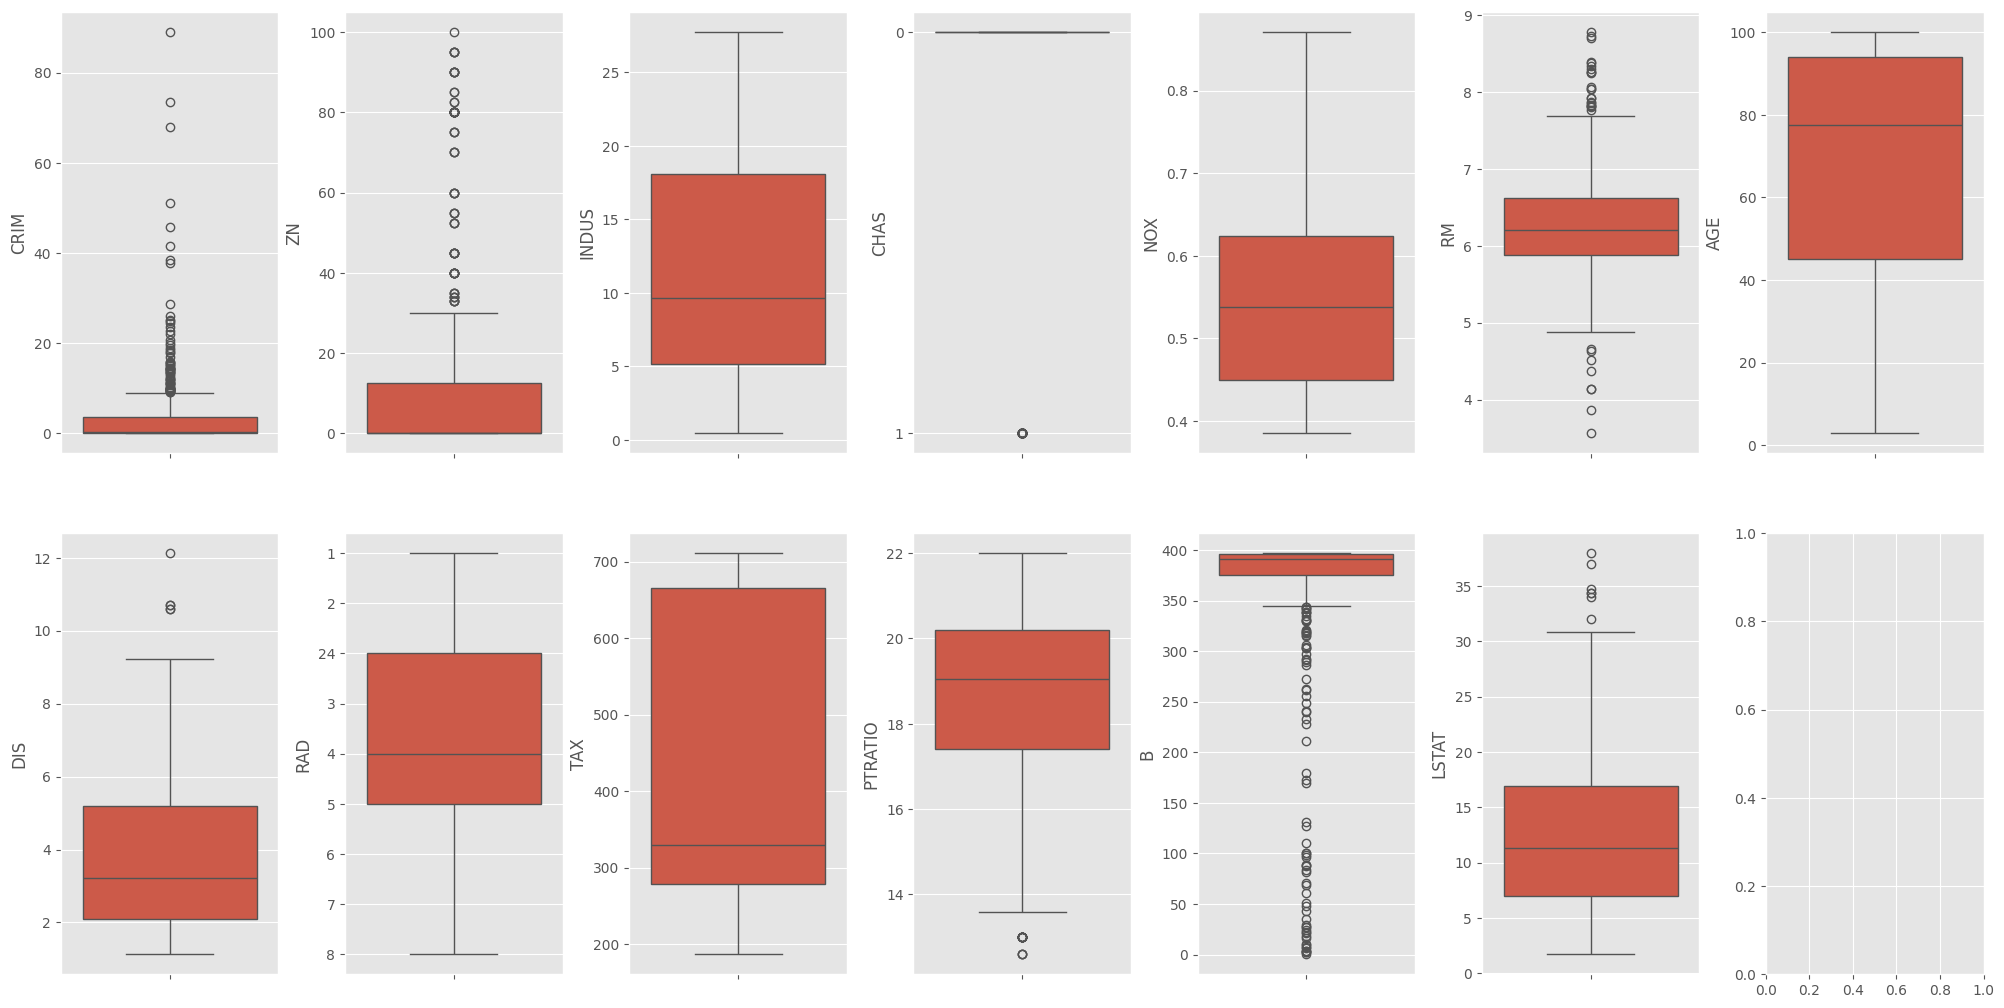

In [ ]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for k,v in df.items():
    sns.boxplot(y=k, data=df, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)


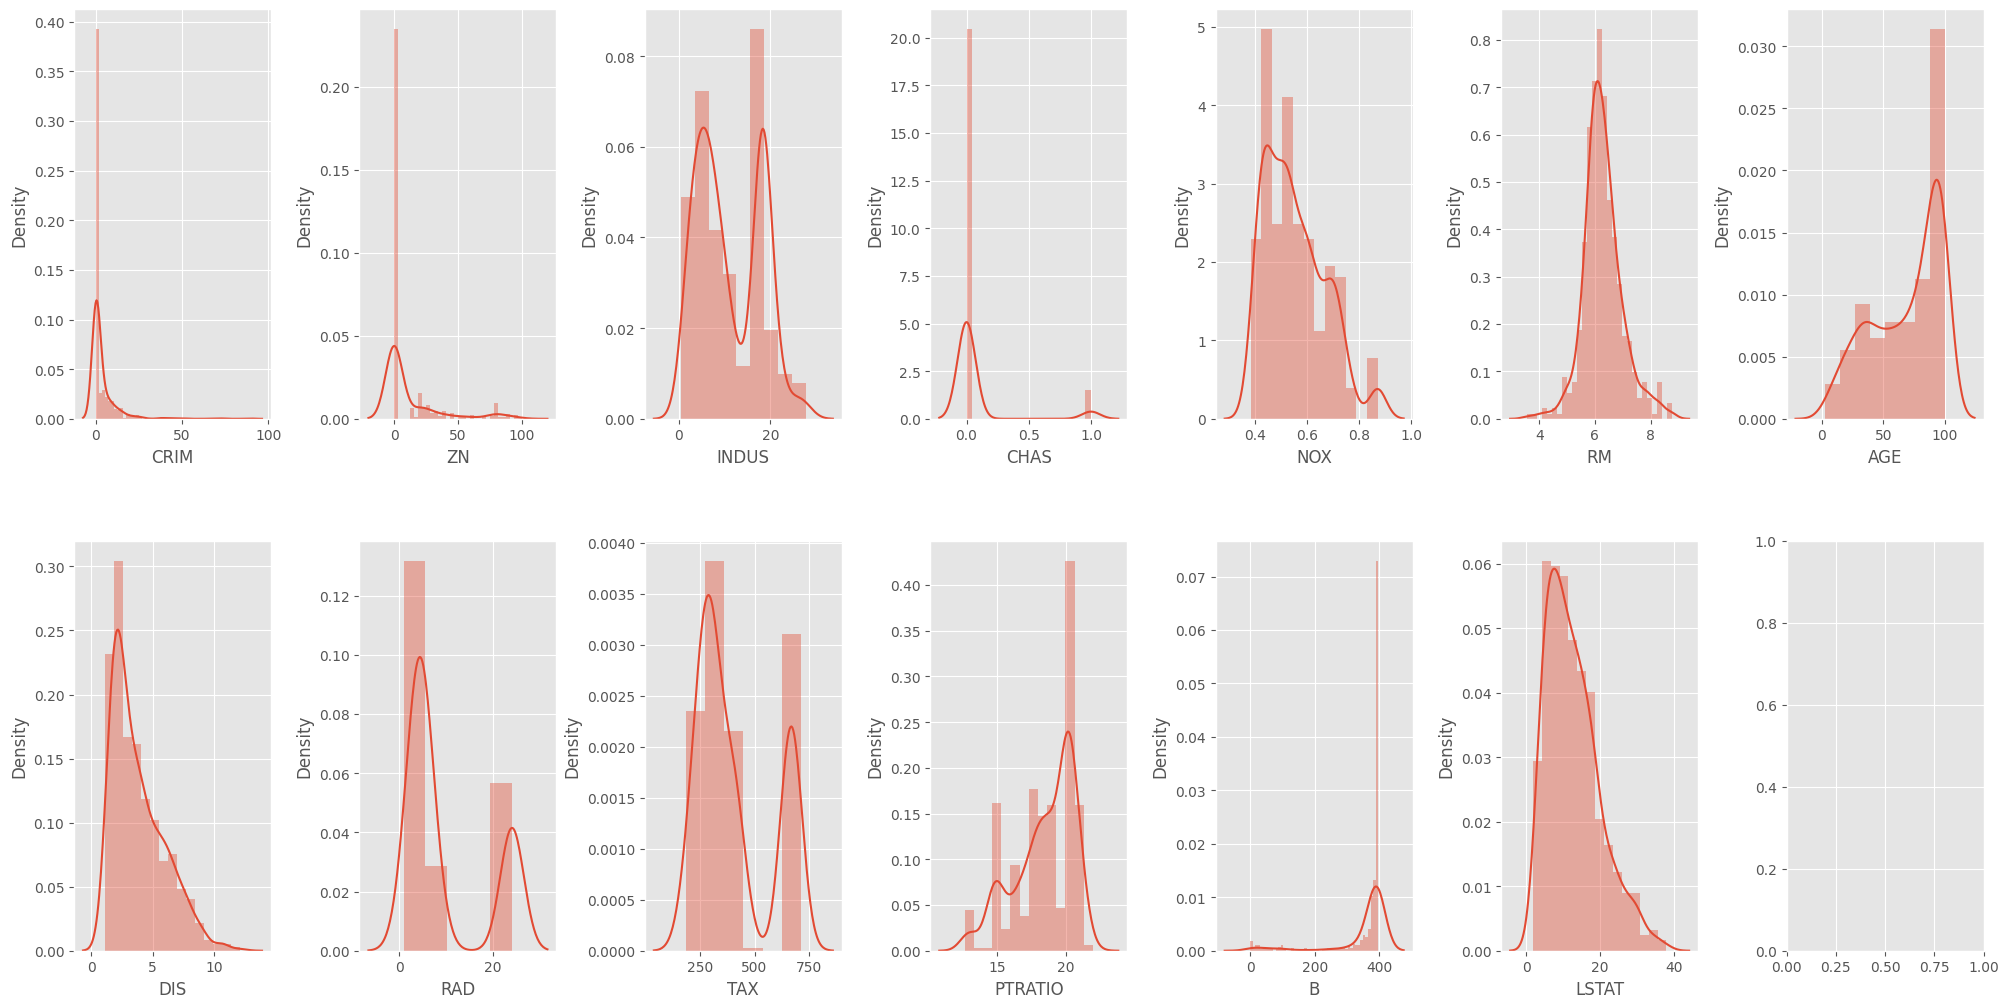

In [ ]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
# distplot = distribution plot
for k,v in df.items():
    sns.distplot(v, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)


In [ ]:
X = df.copy()
y = ds.target.copy()

print("Data shape:", X.shape, "| Target length:", len(y))
print("Columns:", list(X.columns))

Data shape: (506, 13) | Target length: 506
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [ ]:
print(X['CHAS'].dtype)
X['CHAS'] = X['CHAS'].astype(str)
ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False)
X[['CHAS']] = ohe.fit_transform(X[['CHAS']])


category


In [ ]:
X['CHAS'].dtype


dtype('float64')

In [ ]:
print(X['RAD'].dtype)
cats = np.sort(X['RAD'].astype(str).unique())  # ensure ordered categories
ord_enc = OrdinalEncoder(categories=[cats])
X['RAD'] = ord_enc.fit_transform(X[['RAD']]).astype(float)


category


In [ ]:
print(X['RAD'].dtype)


float64


In [ ]:
# 3) Single train/test split (no cross-validation)
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42
)



## 🔵 Phase A — Baseline (Minimal / No Preprocessing)

We start simple to create a reference point:
- LinearRegression
- RandomForestRegressor (mostly insensitive to scaling)
- KNeighborsRegressor (distance-based; baseline here uses no scaling intentionally to highlight the effect later)


In [ ]:
# ---------------------------------------------------------
# PHASE A — Baseline Linear Regression (no preprocessing)
# ---------------------------------------------------------
lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train)

y_pred_base = lr_baseline.predict(X_test)
r2_base = r2_score(y_test, y_pred_base)
print(f"Baseline LinearRegression — R² (test): {r2_base:.4f}")


Baseline LinearRegression — R² (test): 0.6396


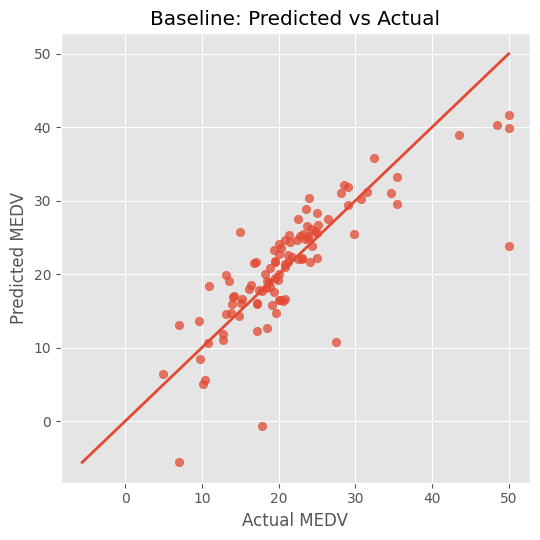

In [ ]:
# Plots for baseline
#  A) Parity: prediction vs actual
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred_base, alpha=0.75)
mn, mx = min(y_test.min(), y_pred_base.min()), max(y_test.max(), y_pred_base.max())
plt.plot([mn, mx], [mn, mx], linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Baseline: Predicted vs Actual")
plt.tight_layout()
plt.show()


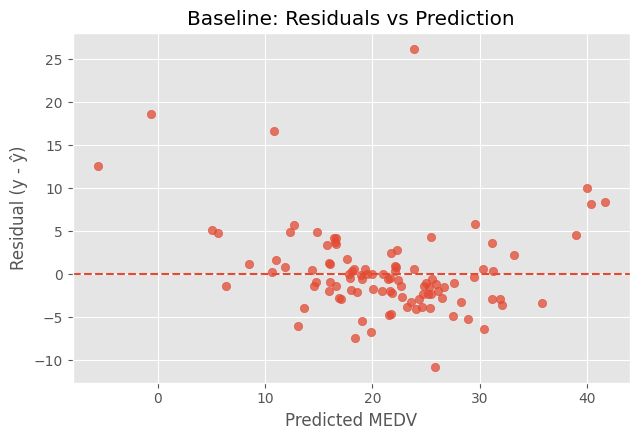

In [ ]:
#  B) Residuals vs prediction
resid_base = y_test - y_pred_base
plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_pred_base, resid_base, alpha=0.75)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted MEDV")
plt.ylabel("Residual (y - ŷ)")
plt.title("Baseline: Residuals vs Prediction")
plt.tight_layout()
plt.show()



## 🟣 Phase B — Full Preprocessing + Feature Engineering + Nonlinearity

Pipeline steps:
1. Numeric: SimpleImputer(median) -> PowerTransformer(yeo-johnson) to tame skew -> RobustScaler  
2. Categorical: OneHotEncoder(handle_unknown='ignore') (e.g., CHAS)  
3. Feature Engineering:
   - PolynomialFeatures(degree=2) on selected columns (LSTAT, RM)
   - SplineTransformer on LSTAT to capture smooth nonlinearities
   - Optional interactions (e.g., RM x LSTAT)

Models compared:
- RidgeCV, LassoCV, ElasticNetCV (regularized linear)
- KNN (with scaling this time)
- HistGradientBoostingRegressor (fast GBDT)
- RandomForestRegressor
- GradientBoostingRegressor


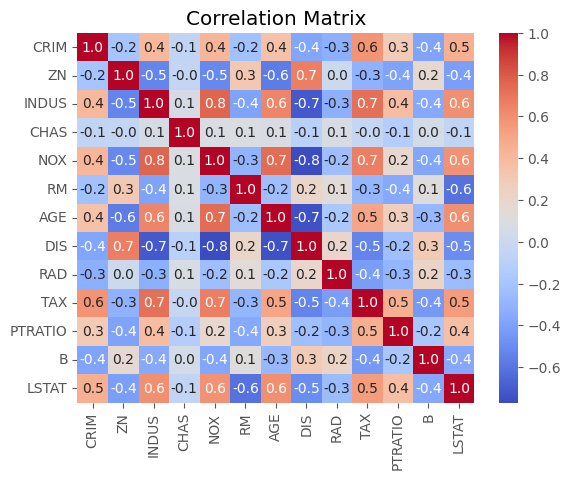

In [ ]:
# ---------------------------------------------------------
# PHASE B — Simple Preprocessing + Nonlinearity
#   - OneHot for nominal: CHAS (0/1)
#   - Ordinal for ordinal: RAD (1..24)
#   - Feature engineering: LSTAT², RM², and LSTAT×RM
#   - Same LinearRegression (no scaling, no CV)
# ---------------------------------------------------------
sns.heatmap(X.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
X.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,3.723320,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,1.898027,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,0.000000,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,2.000000,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,4.000000,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,5.000000,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,8.000000,711.000000,22.000000,396.900000,37.970000


In [ ]:
cols = list(X.columns)

In [ ]:
scaler = MinMaxScaler()
X[cols] = scaler.fit_transform(X[cols])


In [ ]:
X.describe()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,0.040544,0.113636,0.391378,0.069170,0.349167,0.521869,0.676364,0.242381,0.465415,0.422208,0.622929,0.898568,0.301409
std,0.096679,0.233225,0.251479,0.253994,0.238431,0.134627,0.289896,0.191482,0.237253,0.321636,0.230313,0.230205,0.197049
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000851,0.000000,0.173387,0.000000,0.131687,0.445392,0.433831,0.088259,0.250000,0.175573,0.510638,0.945730,0.144040
50%,0.002812,0.000000,0.338343,0.000000,0.314815,0.507281,0.768280,0.188949,0.500000,0.272901,0.686170,0.986232,0.265728
75%,0.041258,0.125000,0.646628,0.000000,0.491770,0.586798,0.938980,0.369088,0.625000,0.914122,0.808511,0.998298,0.420116
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# IQR method for outlier detection
Q1 = X[cols].quantile(0.25)
Q3 = X[cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((X[cols] < (Q1 - 1.5 * IQR)) | (X[cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print("Outliers detected:", outliers.sum())


Outliers detected: 232


In [ ]:
sk = skew(X, nan_policy='omit')
sk

array([ 5.20765239,  2.21906306,  0.29414628,  3.39579929,  0.72714416,
        0.40241467, -0.59718559,  1.00877876,  0.23677504,  0.66796827,
       -0.79994453, -2.88179835,  0.90377074])

In [ ]:
X_log = np.log1p(X)


In [ ]:
sk = skew(X_log, nan_policy='omit')
sk


array([ 4.11650381,  1.96390457,  0.12300093,  3.39579929,  0.40848166,
       -0.1274098 , -0.80436442,  0.73219961, -0.14380312,  0.51006915,
       -1.06685265, -3.07519654,  0.5763296 ])

In [ ]:
# 3) Very light feature engineering (nonlinearity)
if 'LSTAT' in cols:
    X['LSTAT_sq'] = X['LSTAT'] ** 2

if 'RM' in cols:
    X['RM_sq'] = X['RM'] ** 2

if all(col in cols for col in ['LSTAT', 'RM']):
    X['LSTAT_x_RM'] = X['LSTAT'] * X['RM']


In [ ]:
# 3) Single train/test split (no cross-validation)
Xtr, Xte, ytr, yte = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42
)


In [ ]:
Xtr.isna().sum().sum()

np.int64(0)

In [ ]:
# 5) Train a simple LinearRegression on the processed features
lr_proc = LinearRegression()
lr_proc.fit(Xtr, ytr)

y_pred_proc = lr_proc.predict(Xte)
r2_proc = r2_score(y_test, y_pred_proc)
print(f"Processed LinearRegression — R² (test): {r2_proc:.4f}")


Processed LinearRegression — R² (test): 0.7889


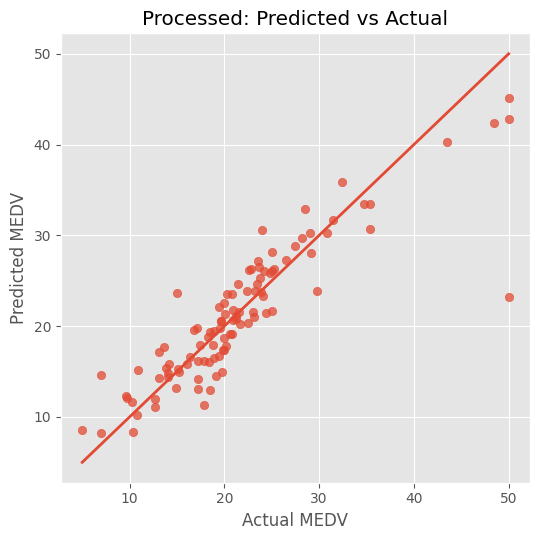

In [ ]:
# 7) Plots for processed model
#  A) Parity
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred_proc, alpha=0.75)
mn, mx = min(y_test.min(), y_pred_proc.min()), max(y_test.max(), y_pred_proc.max())
plt.plot([mn, mx], [mn, mx], linewidth=2)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Processed: Predicted vs Actual")
plt.tight_layout()
plt.show()


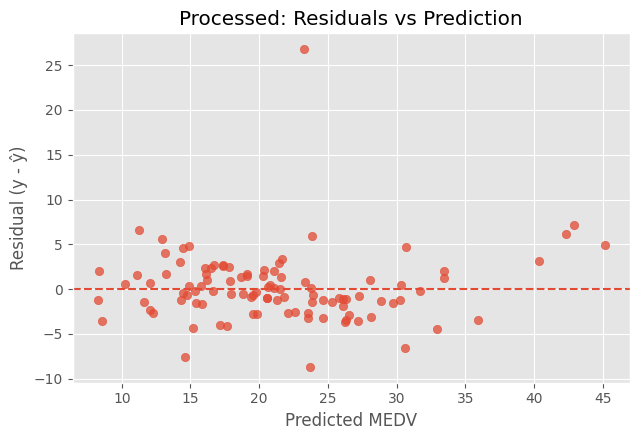

In [ ]:
#  B) Residuals vs prediction
resid_proc = y_test - y_pred_proc
plt.figure(figsize=(6.5, 4.5))
plt.scatter(y_pred_proc, resid_proc, alpha=0.75)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted MEDV")
plt.ylabel("Residual (y - ŷ)")
plt.title("Processed: Residuals vs Prediction")
plt.tight_layout()
plt.show()


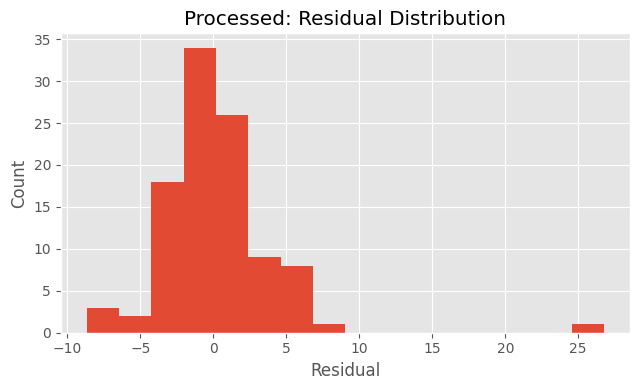

In [ ]:
#  C) Residual histogram (just for a nicer look)
plt.figure(figsize=(6.5, 4.0))
plt.hist(resid_proc, bins=16)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Processed: Residual Distribution")
plt.tight_layout()
plt.show()


In [ ]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(Xtr, y_train)

y_pred_ridge = ridge.predict(Xte)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression — R² (test): {r2_ridge:.4f}")


Ridge Regression — R² (test): 0.7438


In [ ]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(Xtr, y_train)

y_pred_lasso = lasso.predict(Xte)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso Regression — R² (test): {r2_lasso:.4f}")


Lasso Regression — R² (test): 0.6886


In [ ]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)
elastic.fit(Xtr, y_train)

y_pred_elastic = elastic.predict(Xte)
r2_elastic = r2_score(y_test, y_pred_elastic)
print(f"ElasticNet Regression — R² (test): {r2_elastic:.4f}")


ElasticNet Regression — R² (test): 0.6158


In [ ]:
# Compare R² scores of all models neatly
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'Baseline LR'
    ],
    'R2_test': [r2_proc, r2_ridge, r2_lasso, r2_elastic, r2_base]
})

print("\nR² comparison:\n", comparison)



R² comparison:
                    Model   R2_test
0      Linear Regression  0.788865
1       Ridge Regression  0.743753
2       Lasso Regression  0.688643
3  ElasticNet Regression  0.615823
4            Baseline LR  0.639631



### ➕ Optional: Target Transform (Log1p)

MEDV is clipped at 50 in the Boston dataset, and the residuals can be heteroscedastic.  
Using a target transform can sometimes stabilize variance. Below is a quick comparison using TransformedTargetRegressor.



## ✅ Wrap-Up

- Preprocessing + regularization + nonlinearity typically improve performance vs. raw baselines.  
- For fair comparisons, fit transforms on train only (done here via Pipelines).  
- Prefer modern datasets (e.g., California / Ames) for realistic practice and ethics.  
- Extend this notebook by trying:
  - Alternative feature engineering (domain-driven ratios/thresholds)
  - Hyperparameter search with RandomizedSearchCV
  - Robust validation (nested CV) and error analysis by subgroups
